# Block 2 — Load Offline Cache (Replay Buffer)

**Goal.** Load the cached dataset from previous labs to use as a warm-start replay buffer for this session’s online PPO simulation.

**What we’ll do in this block**
- Define canonical paths relative to this notebook (`class03/…`).
- Load `cache/cache.csv` with strict column validation.
- Clean and preview the data (dedupe, drop empties).
- Summarize basic stats so we know what we’re starting with.

**Expected file**
- `./cache/cache.csv` with columns:
  - `prompt`, `baseline_response`, `model_response`, `rm_score`

> If the file is missing or malformed, we’ll fall back to a tiny in-memory demo cache so you can proceed.


In [3]:
# ============================================================
# Block 2 — Load Offline Cache (Replay Buffer)  [Robust Schema]
# ------------------------------------------------------------
# Accepts multiple Lab-02 style schemas and maps them to:
#   prompt, baseline_response, model_response, rm_score
# ============================================================

import os, sys
from pathlib import Path
import pandas as pd
import numpy as np

# --- Paths ---
BASE_DIR   = Path(".").resolve()
CACHE_PATH = BASE_DIR / "cache" / "cache.csv"
UTILS_DIR  = BASE_DIR / "utils"
if str(UTILS_DIR) not in sys.path:
    sys.path.append(str(UTILS_DIR))

print("📁 BASE_DIR   :", BASE_DIR)
print("📄 CACHE_PATH :", CACHE_PATH)

REQUIRED = ["prompt", "baseline_response", "model_response", "rm_score"]

def _load_any_cache(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing cache at {path}")

    df = pd.read_csv(path)
    cols = [c.strip() for c in df.columns]
    df.columns = cols  # normalize whitespace
    found = set(cols)

    # --- CASE A: Already in required schema
    if set(REQUIRED).issubset(found):
        return df[REQUIRED].copy()

    # --- CASE B: Typical Lab-02 export
    # e.g., ['prompt','completion','reward','logprob','adv','logprob_new','reward_new']
    candidates = {
        "prompt": None,
        "baseline_response": None,
        "model_response": None,
        "rm_score": None,
    }

    # Prompt
    for k in ["prompt", "input", "instruction"]:
        if k in found:
            candidates["prompt"] = k
            break

    # Model response (completion)
    for k in ["completion", "response", "output", "model_response"]:
        if k in found:
            candidates["model_response"] = k
            break

    # Baseline response (if absent, leave blank or duplicate model as a fallback)
    for k in ["baseline_response", "baseline", "reference", "old_response"]:
        if k in found:
            candidates["baseline_response"] = k
            break

    # Reward score
    for k in ["rm_score", "reward", "score", "rm"]:
        if k in found:
            candidates["rm_score"] = k
            break

    # Build mapped frame with sensible fallbacks
    def _take(colname, default=None):
        src = candidates[colname]
        if src is None:
            return default
        return df[src]

    mapped = pd.DataFrame({
        "prompt": _take("prompt", default="").astype(str),
        "model_response": _take("model_response", default="").astype(str),
        "baseline_response": _take(
            "baseline_response",
            default=_take("model_response", default="").astype(str)  # fallback: duplicate model_response
        ).astype(str),
        "rm_score": pd.to_numeric(_take("rm_score", default=np.nan), errors="coerce"),
    })

    # Validate at least prompt + model_response exist
    if not mapped["prompt"].any():
        raise ValueError("Could not map a 'prompt' column from your cache.")
    if (mapped["model_response"].str.len() == 0).all():
        raise ValueError("Could not map a model response (e.g., 'completion'/'response') from your cache.")

    return mapped

# ---- Load, clean, summarize ----
df_cache = _load_any_cache(CACHE_PATH).copy()

# Normalize strings
for col in ["prompt", "baseline_response", "model_response"]:
    df_cache[col] = df_cache[col].astype(str).str.strip()

# rm_score: if entirely missing, initialize to 0; else keep numeric
if df_cache["rm_score"].isna().all():
    df_cache["rm_score"] = 0.0
else:
    df_cache["rm_score"] = pd.to_numeric(df_cache["rm_score"], errors="coerce").fillna(0.0)

before = len(df_cache)
df_cache = df_cache.dropna(subset=["prompt"])
df_cache = df_cache[df_cache["prompt"].str.len() > 0]
df_cache = df_cache.drop_duplicates(subset=["prompt", "model_response"]).reset_index(drop=True)
after = len(df_cache)

print("\n✅ Cache loaded & mapped to required schema.")
print(f"   Rows (before → after): {before} → {after}")
print(f"   Columns: {list(df_cache.columns)}")

s = df_cache["rm_score"].astype(float)
print(f"   rm_score: mean={s.mean():.3f}, std={s.std(ddof=1):.3f}, min={s.min():.3f}, max={s.max():.3f}")

# Preview
display(df_cache.head(5))

# Fast subset for iterations
CACHE_SMALL = df_cache.sample(min(64, len(df_cache)), random_state=42).reset_index(drop=True)
print(f"\n📌 CACHE_SMALL prepared with {len(CACHE_SMALL)} rows.")

# Session context
class LabContext:
    cache_df = df_cache
    cache_small_df = CACHE_SMALL
    base_dir = BASE_DIR
    cache_path = CACHE_PATH
    utils_dir = UTILS_DIR

CTX = LabContext()
print("\n🔗 CTX ready (cache_df, cache_small_df, base_dir, cache_path, utils_dir).")


📁 BASE_DIR   : C:\Users\murth\Desktop\NLP+RL\code\class03
📄 CACHE_PATH : C:\Users\murth\Desktop\NLP+RL\code\class03\cache\cache.csv

✅ Cache loaded & mapped to required schema.
   Rows (before → after): 300 → 72
   Columns: ['prompt', 'model_response', 'baseline_response', 'rm_score']
   rm_score: mean=-0.046, std=0.043, min=-0.134, max=0.026


,prompt,model_response,baseline_response,rm_score
0,Rephrase politely: You are wrong. (nicely),Rephrase politely: You are wrong. (nicely) [Ve...,Rephrase politely: You are wrong. (nicely) [Ve...,-0.056229
1,Rephrase politely: You are wrong. (nicely),Rephrase politely: You are wrong. (nicely) [Ve...,Rephrase politely: You are wrong. (nicely) [Ve...,-0.051312
2,Rephrase politely: You are wrong. (nicely),Rephrase politely: You are wrong. (nicely) [Ve...,Rephrase politely: You are wrong. (nicely) [Ve...,-0.053463
3,Answer concisely: Why is the sky blue? (for a ...,Answer concisely: Why is the sky blue? (for a ...,Answer concisely: Why is the sky blue? (for a ...,-0.033126
4,Answer concisely: Why is the sky blue? (for a ...,Answer concisely: Why is the sky blue? (for a ...,Answer concisely: Why is the sky blue? (for a ...,-0.029764



📌 CACHE_SMALL prepared with 64 rows.

🔗 CTX ready (cache_df, cache_small_df, base_dir, cache_path, utils_dir).


# Block 3 — Load Reward Model (Rθ) & Tokenizer Bootstrap

**Goal.** Initialize a lightweight Reward Model `Rθ` and a tokenizer for scoring `(x, y)` pairs.  
We avoid SentencePiece to keep Windows installs simple, so we’ll use a GPT-2 tokenizer (byte-BPE).

**What this block does**
- Loads a tokenizer (`gpt2`) and configures padding (GPT-2 lacks a native pad token).
- Defines a tiny reward model (embedding → mean-pool → linear head), matching the mock saved in `./data/reward_model.pt`.
- Loads `Rθ` from `./data/reward_model.pt` if present; otherwise initializes fresh (with a clear warning).
- Provides a helper `score_with_rm()` to score lists of `(prompt, response)` pairs.
- Smoke-tests on a small slice of the cache (baseline vs model responses) and prints quick stats.

> **Note:** The mock `Rθ` is for teaching PPO mechanics (KL-control/stability). It’s not meant to be a strong semantic judge.


In [4]:
# ============================================================
# Block 3 — Load Reward Model (Rθ) & Tokenizer Bootstrap
# ------------------------------------------------------------
# - No file writes; ONLINE display only.
# - Uses GPT-2 tokenizer (no SentencePiece dependency).
# - Loads TinyRewardModel weights from ./data/reward_model.pt if available.
# ============================================================

import os, sys
from pathlib import Path
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from transformers import AutoTokenizer

# --- Access Lab context from Block 2 ---
try:
    CTX  # noqa: F821
except NameError as e:
    raise RuntimeError("CTX not found. Please run Block 2 first.") from e

BASE_DIR = CTX.base_dir
DATA_PATH = BASE_DIR / "data" / "reward_model.pt"

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Using device: {device}")

# --- Tokenizer (GPT-2; pad_token -> eos_token for batching) ---
tokenizer = AutoTokenizer.from_pretrained("gpt2", use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"  # helpful for generation later
vocab_size = tokenizer.vocab_size
print(f"🔤 Tokenizer: gpt2 | vocab_size={vocab_size}, pad_token_id={tokenizer.pad_token_id}")

# --- Tiny Reward Model definition (teaching model) ---
class TinyRewardModel(nn.Module):
    """
    A very small reward model for lab use:
      - Token Embedding (size: vocab_size x hidden)
      - Mean-pool across sequence length
      - Linear head → scalar reward
    """
    def __init__(self, vocab_size: int, hidden: int = 64):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, hidden)
        self.head = nn.Linear(hidden, 1)

    def forward(self, input_ids: torch.LongTensor) -> torch.Tensor:
        # input_ids: [B, T]
        x = self.emb(input_ids)              # [B, T, H]
        x = x.mean(dim=1)                    # [B, H]  (bag-of-words style)
        r = self.head(x).squeeze(-1)         # [B]
        return r

# --- Instantiate and (optionally) load weights ---
rm = TinyRewardModel(vocab_size=vocab_size, hidden=64)
if DATA_PATH.exists():
    try:
        state = torch.load(DATA_PATH, map_location="cpu")
        # load with strict=False in case saved vocab size differs
        missing, unexpected = rm.load_state_dict(state, strict=False)
        if missing or unexpected:
            print(f"⚠️  Loaded reward_model.pt with shape mismatches. "
                  f"missing={len(missing)}, unexpected={len(unexpected)} "
                  f"(this is fine for the mock model).")
        print(f"✅ Loaded Rθ from {DATA_PATH}")
    except Exception as e:
        print(f"⚠️  Could not load saved reward model, using fresh init. Details: {e}")
else:
    print(f"⚠️  {DATA_PATH} not found — initializing Rθ with random weights.")

rm.to(device).eval()

# --- Helper: Score (prompt, response) pairs with Rθ ---
@torch.inference_mode()
def score_with_rm(prompts, responses, max_len: int = 256, batch_size: int = 16):
    """
    Returns: np.ndarray of rewards (float)
    We simply concatenate: text = prompt + ' ' + response,
    tokenize, feed IDs to TinyRewardModel, and get a scalar per row.
    """
    assert len(prompts) == len(responses)
    rewards = []

    for i in range(0, len(prompts), batch_size):
        batch_prompts = prompts[i:i+batch_size]
        batch_resps   = responses[i:i+batch_size]
        texts = [f"{p.strip()} {r.strip()}" for p, r in zip(batch_prompts, batch_resps)]

        enc = tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt",
        )
        input_ids = enc["input_ids"].to(device)
        r = rm(input_ids)  # [B]
        rewards.append(r.detach().cpu())

    return torch.cat(rewards, dim=0).numpy()

# --- Smoke test on a small slice of cache: baseline vs model_response ---
df = CTX.cache_small_df
n_show = min(5, len(df))
print(f"\n🔎 Smoke test on {len(df)} rows (showing {n_show})")

baseline_scores = score_with_rm(df["prompt"].tolist(), df["baseline_response"].tolist())
model_scores    = score_with_rm(df["prompt"].tolist(), df["model_response"].tolist())

def _stats(a):
    a = np.asarray(a, dtype=float)
    return dict(mean=float(a.mean()), std=float(a.std(ddof=1)) if len(a) > 1 else 0.0,
                min=float(a.min()), max=float(a.max()))

print("Baseline scores:", _stats(baseline_scores))
print("Model    scores:", _stats(model_scores))

# Preview a few rows with scores
preview = df.head(n_show).copy()
preview["rm_baseline"] = baseline_scores[:n_show]
preview["rm_model"]    = model_scores[:n_show]
display(preview[["prompt", "baseline_response", "model_response", "rm_baseline", "rm_model"]])


🖥️  Using device: cpu


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

c:\Users\murth\Desktop\NLP+RL\code\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\murth\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

🔤 Tokenizer: gpt2 | vocab_size=50257, pad_token_id=50256
⚠️  Could not load saved reward model, using fresh init. Details: Error(s) in loading state_dict for TinyRewardModel:
	size mismatch for emb.weight: copying a param with shape torch.Size([30522, 64]) from checkpoint, the shape in current model is torch.Size([50257, 64]).

🔎 Smoke test on 64 rows (showing 5)
Baseline scores: {'mean': 0.07727036002324894, 'std': 0.1475943806378037, 'min': -0.2506309151649475, 'max': 0.2678806185722351}
Model    scores: {'mean': 0.07727036002324894, 'std': 0.1475943806378037, 'min': -0.2506309151649475, 'max': 0.2678806185722351}


,prompt,baseline_response,model_response,rm_baseline,rm_model
0,Answer concisely: Why is the sky blue? (for a ...,Answer concisely: Why is the sky blue? (for a ...,Answer concisely: Why is the sky blue? (for a ...,0.001629,0.001629
1,Rephrase politely: You are wrong. (briefly),Rephrase politely: You are wrong. (briefly) [V...,Rephrase politely: You are wrong. (briefly) [V...,0.198624,0.198624
2,Write a polite reply to: I need this report ur...,Write a polite reply to: I need this report ur...,Write a polite reply to: I need this report ur...,0.096800,0.096800
3,Rephrase politely: You are wrong. (nicely),Rephrase politely: You are wrong. (nicely) [Ve...,Rephrase politely: You are wrong. (nicely) [Ve...,0.223778,0.223778
4,Rephrase politely: You are wrong. (in one sent...,Rephrase politely: You are wrong. (in one sent...,Rephrase politely: You are wrong. (in one sent...,0.205565,0.205565


# Block 4 — Initialize Policy (πϕ) & Reference (π_ref), Freeze Bottom Layers

**Goal.** Create a small causal LM policy (`distilgpt2`) for fast iterations, clone a frozen **reference policy** (`π_ref`) for KL control, and partially freeze the trainable policy to reduce drift/overfit.

**What this block does**
- Loads `distilgpt2` as **policy** `πϕ` and **reference** `π_ref` (weights identical at start).
- **Freezes the bottom N transformer layers** of the policy (teaching PPO with partial adaptation).
- Sets up an **AdamW optimizer** for the remaining trainable parameters.
- Provides helpers to compute:
  - per-token **log-probs** of the response tokens conditioned on the prompt,
  - **entropy** over response tokens,
  - **KL(πϕ || π_ref)** over response tokens.

**Notes**
- We reuse the GPT-2 tokenizer from Block 3 (compatible with distilGPT2).
- No file writes; everything is displayed inline.


In [6]:
# ============================================================
# Block 4 — Initialize Policy (πϕ) & Reference (π_ref), Freeze Bottom Layers
# ------------------------------------------------------------
# - Loads distilgpt2 for speed.
# - Freezes bottom N layers of the policy (teaching setting).
# - Sets up optimizer.
# - Utilities to compute logprobs/entropy/KL on response tokens only.
# ============================================================

import math
import copy
from typing import Dict, Tuple, List

import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from transformers import AutoModelForCausalLM, get_linear_schedule_with_warmup

# --- Access tokenizer & CTX from previous blocks ---
try:
    tokenizer  # from Block 3
    CTX
except NameError as e:
    raise RuntimeError("Missing prerequisites. Run Blocks 2 and 3 first.") from e

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Hyperparams (fallbacks if Block 1 constants weren't defined here) ---
LR_POLICY = globals().get("LR_POLICY", 1e-5)
FREEZE_N_BOTTOM_LAYERS = globals().get("FREEZE_N_BOTTOM_LAYERS", 3)
PPO_CLIP_EPS = globals().get("PPO_CLIP_EPS", 0.2)

# --- Load policy and reference (identical init) ---
policy = AutoModelForCausalLM.from_pretrained("distilgpt2").to(device)
policy.train()  # will partially freeze below

ref_model = copy.deepcopy(policy).to(device)
for p in ref_model.parameters():
    p.requires_grad_(False)
ref_model.eval()

# --- Freeze bottom N transformer blocks in the policy ---
# distilGPT2 has 6 blocks at: policy.transformer.h[0..5]
num_layers = len(policy.transformer.h)
freeze_upto = min(FREEZE_N_BOTTOM_LAYERS, num_layers)
for layer_idx in range(freeze_upto):
    for p in policy.transformer.h[layer_idx].parameters():
        p.requires_grad_(False)

# (Optional) keep embeddings frozen too? We'll keep them trainable for this lab.
# If you want to freeze them: for p in policy.transformer.wte.parameters(): p.requires_grad_(False)

# --- Inspect trainable vs frozen parameter counts ---
def count_params(named_params):
    total, trainable = 0, 0
    for n, p in named_params:
        n_params = p.numel()
        total += n_params
        if p.requires_grad:
            trainable += n_params
    return total, trainable

total, trainable = count_params(policy.named_parameters())
print(f"🧠 distilGPT2 layers: {num_layers}")
print(f"🧊 Frozen bottom layers: {freeze_upto}")
print(f"🔢 Params — total: {total/1e6:.2f}M | trainable: {trainable/1e6:.2f}M")

# --- Optimizer & (simple) scheduler for policy ---
optim = torch.optim.AdamW((p for p in policy.parameters() if p.requires_grad), lr=LR_POLICY, betas=(0.9, 0.999), weight_decay=0.01)
# We'll create a scheduler later once we know the number of steps; for now keep it None
sched = None

# ============================================================
# Helper functions: logprobs, entropy, KL (on response tokens only)
# ============================================================

def _concat_and_mark(prompt_texts: List[str], resp_texts: List[str], max_len: int = 256) -> Dict[str, torch.Tensor]:
    """
    Tokenize concatenated prompt+response; return tensors and a mask that marks response positions.
    Left padding is fine; we mark indices that belong to the response span per row.
    """
    assert len(prompt_texts) == len(resp_texts)
    batch_texts = [ (p.strip(), r.strip()) for p, r in zip(prompt_texts, resp_texts) ]
    # Tokenize separately to know prompt lengths
    enc_p = tokenizer([p for p, _ in batch_texts], padding=True, truncation=True, max_length=max_len, return_tensors="pt")
    enc_r = tokenizer([r for _, r in batch_texts], padding=True, truncation=True, max_length=max_len, return_tensors="pt")

    # Now build combined (prompt + response) per row
    input_ids_list, attention_masks_list, resp_masks_list = [], [], []
    for i in range(len(batch_texts)):
        p_ids = enc_p["input_ids"][i].tolist()
        r_ids = enc_r["input_ids"][i].tolist()

        # Remove left-pad token IDs at the front (if any) to avoid counting them
        def strip_left_pad(ids):
            # tokenizer.pad_token_id is safe by Block 3
            while len(ids) and ids[0] == tokenizer.pad_token_id:
                ids.pop(0)
            return ids
        p_ids = strip_left_pad(p_ids)
        r_ids = strip_left_pad(r_ids)

        # Truncate to keep total within max_len
        keep_for_resp = max_len - min(len(p_ids), max_len//2)  # heuristic: reserve half for resp if needed
        p_ids = p_ids[-(max_len - 1):]  # -1 to leave space for at least 1 resp token
        r_ids = r_ids[:keep_for_resp]

        all_ids = p_ids + r_ids
        all_ids = all_ids[:max_len]
        pad_len = max_len - len(all_ids)
        input_ids = [tokenizer.pad_token_id] * pad_len + all_ids

        # Attention mask (1 for non-pad)
        attn = [0] * pad_len + [1] * len(all_ids)

        # Response mask: 1 for positions that come from response tokens
        resp_mask = [0] * pad_len + ([0] * len(p_ids) + [1] * min(len(r_ids), max_len - len(p_ids)))

        input_ids_list.append(input_ids)
        attention_masks_list.append(attn)
        resp_masks_list.append(resp_mask)

    input_ids = torch.tensor(input_ids_list, dtype=torch.long, device=device)
    attention_mask = torch.tensor(attention_masks_list, dtype=torch.long, device=device)
    resp_mask = torch.tensor(resp_masks_list, dtype=torch.bool, device=device)
    return {"input_ids": input_ids, "attention_mask": attention_mask, "resp_mask": resp_mask}

def logprobs_on_response(model: AutoModelForCausalLM, input_ids: torch.Tensor, attention_mask: torch.Tensor, resp_mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Compute token-level logprobs for the NEXT token; then gather only those
    at response positions (standard causal LM convention).
    Returns:
      logprobs_resp: [B, T] (masked elsewhere), logits: [B, T, V]
    """
    out = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = out.logits  # [B, T, V]

    # Shift for next-token logprob
    logprobs = F.log_softmax(logits, dim=-1)  # [B, T, V]
    # Gather the logprob of the actually observed next token
    # For token t, next-token is input_ids[:, t+1]; last token has no next → pad
    next_tokens = torch.roll(input_ids, shifts=-1, dims=1)
    # Don't use next at last position: zero the mask there
    not_last = torch.ones_like(resp_mask)
    not_last[:, -1] = False

    idx = next_tokens.unsqueeze(-1)  # [B, T, 1]
    next_token_lp = torch.gather(logprobs, dim=-1, index=idx).squeeze(-1)  # [B, T]

    # Keep only positions that are both response positions and not last
    resp_token_mask = resp_mask & not_last
    logprobs_resp = torch.where(resp_token_mask, next_token_lp, torch.zeros_like(next_token_lp))
    return logprobs_resp, logits

def entropy_on_response(logits: torch.Tensor, resp_mask: torch.Tensor) -> torch.Tensor:
    logprob = F.log_softmax(logits, dim=-1)
    prob = logprob.exp()
    ent = -(prob * logprob).sum(dim=-1)  # [B, T]
    # Mask to response tokens only
    ent = torch.where(resp_mask, ent, torch.zeros_like(ent))
    return ent  # [B, T]

@torch.no_grad()
def kl_on_response(policy_logits: torch.Tensor, ref_logits: torch.Tensor, resp_mask: torch.Tensor) -> torch.Tensor:
    """
    KL(πϕ || π_ref) on response tokens only, tokenwise then averaged per sequence.
    """
    p_logprob = F.log_softmax(policy_logits, dim=-1)
    q_logprob = F.log_softmax(ref_logits, dim=-1)
    p_prob = p_logprob.exp()
    kl_tok = (p_prob * (p_logprob - q_logprob)).sum(dim=-1)  # [B, T]
    kl_tok = torch.where(resp_mask, kl_tok, torch.zeros_like(kl_tok))
    # mean over response-token count (avoid dividing by zero)
    denom = resp_mask.sum(dim=-1).clamp(min=1).float()
    return kl_tok.sum(dim=-1) / denom  # [B]

# --- Quick smoke test on a tiny batch from the cache ---
df = CTX.cache_small_df.head(4)
batch = _concat_and_mark(df["prompt"].tolist(), df["model_response"].tolist(), max_len=256)

with torch.no_grad():
    lp_pol, logits_pol = logprobs_on_response(policy, **batch)
    lp_ref, logits_ref = logprobs_on_response(ref_model, **batch)
    ent = entropy_on_response(logits_pol, batch["resp_mask"])
    kl_seq = kl_on_response(logits_pol, logits_ref, batch["resp_mask"])

# Summaries (online display)
def _masked_mean(x: torch.Tensor, mask: torch.Tensor) -> float:
    num = (x * mask).sum().item()
    den = mask.sum().item() or 1
    return num / den

print("\n✅ Policy & reference ready.")
print(f"   Test — avg token logprob (policy, response-only): {_masked_mean(lp_pol, batch['resp_mask']):.4f}")
print(f"   Test — avg token entropy (policy, response-only): {_masked_mean(ent, batch['resp_mask']):.4f}")
print(f"   Test — mean KL(π||π_ref) per seq: {kl_seq.mean().item():.4f}")

# Keep conveniences for later blocks
class PolicyBundle:
    policy = policy
    ref = ref_model
    optim = optim
    sched = sched
    tokenizer = tokenizer
    device = device
    freeze_upto = freeze_upto
    num_layers = num_layers

PB = PolicyBundle()
print("🔗 PB prepared (policy, ref, optim, sched, tokenizer, device).")


🧠 distilGPT2 layers: 6
🧊 Frozen bottom layers: 3
🔢 Params — total: 81.91M | trainable: 60.65M

✅ Policy & reference ready.
   Test — avg token logprob (policy, response-only): -7.3293
   Test — avg token entropy (policy, response-only): 3.9807
   Test — mean KL(π||π_ref) per seq: 1.7929
🔗 PB prepared (policy, ref, optim, sched, tokenizer, device).


# Block 5 — Online Rollout Generation (Sampling & Token Stats)

**Goal.** For a batch of prompts, **sample new responses** from the current policy (πϕ) and compute per-sequence token statistics needed for PPO:
- Store generated responses (text).
- Recompute token-level **log-probs** for the response tokens under πϕ.
- Compute **entropy** on response tokens.
- Compute **KL(πϕ || π_ref)** on response tokens (for diagnostics & β-controller in Block 7).

**Notes**
- We use `distilgpt2.generate` with `do_sample=True`, `temperature=0.7`, and `top_p=0.9`.
- For clean measurement, we **re-tokenize** `(prompt, response)` pairs using the helper from Block 4 (`_concat_and_mark`) and then call our utilities to get log-probs / entropy / KL.
- No file writes; results are kept in memory (`ROLLOUTS_LAST` list).


In [7]:
# ============================================================
# Block 5 — Online Rollout Generation (Sampling & Token Stats)
# ------------------------------------------------------------
# - Generates responses from πϕ for a set of prompts.
# - Captures: response text, token logprobs (policy), entropy, KL vs π_ref.
# - Keeps results in-memory for Block 6 (advantages) and Block 7 (PPO).
# ============================================================

from typing import List, Dict, Any
import torch
import numpy as np

# --- Safety checks for prerequisites ---
try:
    CTX, PB
    _concat_and_mark
    logprobs_on_response
    entropy_on_response
    kl_on_response
except NameError as e:
    raise RuntimeError("Missing prerequisites. Run Blocks 2–4 first.") from e

device     = PB.device
tokenizer  = PB.tokenizer
policy     = PB.policy
ref_model  = PB.ref

# --- Rollout hyperparameters (you can tweak interactively) ---
ROLLOUT_TEMPERATURE = globals().get("ROLLOUT_TEMPERATURE", 0.7)
TOP_P               = 0.9
MAX_NEW_TOKENS      = 96
GEN_BATCH_SIZE      = 8   # prompts per generation call (keep small for CPU)

def _generate_responses(prompts: List[str]) -> List[str]:
    """
    Use πϕ to generate responses for each prompt via nucleus sampling.
    Returns a list of response strings (no prefixes/special tokens).
    """
    outs: List[str] = []
    for i in range(0, len(prompts), GEN_BATCH_SIZE):
        batch = prompts[i:i+GEN_BATCH_SIZE]
        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=256,
        ).to(device)

        gen = policy.generate(
            **enc,
            do_sample=True,
            temperature=ROLLOUT_TEMPERATURE,
            top_p=TOP_P,
            max_new_tokens=MAX_NEW_TOKENS,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
        # Extract only the newly generated part (after the prompt length)
        # Here we decode the full sequence, then subtract prompt text by string diff,
        # which is robust to left padding. Simpler for teaching than token slicing.
        for j, full_ids in enumerate(gen):
            full_text = tokenizer.decode(full_ids, skip_special_tokens=True)
            prompt_text = batch[j]
            # Heuristic split: try to remove the prompt prefix textually
            if full_text.startswith(prompt_text):
                resp_text = full_text[len(prompt_text):].strip()
            else:
                # Fallback: if decoding changed spacing, just take the tail words
                resp_text = full_text[-512:].strip()
            outs.append(resp_text if resp_text else "")
    return outs

def sample_rollouts(prompts: List[str]) -> List[Dict[str, Any]]:
    """
    For each prompt:
      - Sample response with πϕ
      - Recompute token stats on response tokens (logprob, entropy, KL)
    Returns a list of dicts with keys:
      prompt, response, lp_mean, ent_mean, kl_mean, resp_len
      plus raw tensors for later PPO (kept lightweight).
    """
    responses = _generate_responses(prompts)

    # Token stats via our helpers (Block 4)
    batch = _concat_and_mark(prompts, responses, max_len=256)

    with torch.no_grad():
        lp_pol, logits_pol = logprobs_on_response(policy, **batch)
        lp_ref, logits_ref = logprobs_on_response(ref_model, **batch)
        ent_tok            = entropy_on_response(logits_pol, batch["resp_mask"])
        kl_seq             = kl_on_response(logits_pol, logits_ref, batch["resp_mask"])

    # Aggregate per-sequence metrics
    resp_mask = batch["resp_mask"]
    resp_len  = resp_mask.sum(dim=1).to(torch.int).cpu().numpy()

    def masked_mean_per_seq(x: torch.Tensor, mask: torch.Tensor) -> np.ndarray:
        x = x.detach().cpu()
        m = mask.detach().cpu()
        num = (x * m).sum(dim=1)
        den = m.sum(dim=1).clamp(min=1)
        return (num / den).numpy()

    lp_mean  = masked_mean_per_seq(lp_pol, resp_mask)
    ent_mean = masked_mean_per_seq(ent_tok, resp_mask)
    kl_mean  = kl_seq.detach().cpu().numpy()

    rollouts = []
    for i in range(len(prompts)):
        rollouts.append({
            "prompt": prompts[i],
            "response": responses[i],
            "lp_mean": float(lp_mean[i]),
            "ent_mean": float(ent_mean[i]),
            "kl_mean": float(kl_mean[i]),
            "resp_len": int(resp_len[i]),
            # Keep items needed for PPO in Block 7 (we’ll recompute as needed too)
            "cached": {
                "batch_inputs": {  # minimal tensors to recompute grads later if needed
                    "input_ids": batch["input_ids"][i:i+1].detach().clone(),
                    "attention_mask": batch["attention_mask"][i:i+1].detach().clone(),
                    "resp_mask": batch["resp_mask"][i:i+1].detach().clone(),
                }
            }
        })
    return rollouts

# --- Demo: take a small slice of prompts and sample an "online burst" ---
df = CTX.cache_small_df
PROMPTS_DEMO = df["prompt"].tolist()[:min(12, len(df))]  # small batch for speed

ROLLOUTS_LAST = sample_rollouts(PROMPTS_DEMO)

# Quick ONLINE preview
import pandas as pd
preview = pd.DataFrame(
    [
        {
            "prompt": r["prompt"][:60] + ("…" if len(r["prompt"]) > 60 else ""),
            "response": r["response"][:60] + ("…" if len(r["response"]) > 60 else ""),
            "lp_mean": r["lp_mean"],
            "ent_mean": r["ent_mean"],
            "kl_mean": r["kl_mean"],
            "resp_len": r["resp_len"],
        }
        for r in ROLLOUTS_LAST[:5]
    ]
)
print(f"✅ Generated {len(ROLLOUTS_LAST)} rollouts (showing 5):")
display(preview)


✅ Generated 12 rollouts (showing 5):


,prompt,response,lp_mean,ent_mean,kl_mean,resp_len
0,Answer concisely: Why is the sky blue? (for a ...,"In this case, the sky blue is the brightest, w...",-4.783105,3.552342,1.751747,96
1,Rephrase politely: You are wrong. (briefly),,0.000000,0.000000,0.000000,0
2,Write a polite reply to: I need this report ur...,,0.000000,0.000000,0.000000,0
3,Rephrase politely: You are wrong. (nicely),,0.000000,0.000000,0.000000,0
4,Rephrase politely: You are wrong. (in one sent...,,0.000000,0.000000,0.000000,0


# Block 6 — Reward Scoring (Rθ) & Advantage Computation (Aₜ)

**Goal.** Convert our online rollouts into training-ready tuples by:
1) Scoring each `(prompt, response)` with the Reward Model `Rθ`.
2) Estimating a **value baseline** `Vψ` using a tiny critic trained on response features.
3) Computing **advantages** `Aₜ = Rθ(x,y) − Vψ(x,y)` and (optionally) standardizing them.

**What this block does**
- Uses `score_with_rm()` (from Block 3) to get scalar rewards for rollouts.
- Extracts response **features** from the policy’s last hidden states (mean over response tokens).
- Trains a **small critic MLP** (few quick steps) to fit rewards with MSE.
- Computes `Aₜ` and prepares an **ADV_BUFFER** with everything PPO needs:
  - `input_ids`, `attention_mask`, `resp_mask`
  - `old_logprobs_resp` (policy’s log-probs at sampling time)
  - `advantages`, `values`, `rewards`

> Notes  
> • We avoid any file writes; everything stays in memory.  
> • If you want a “pure demo,” you can toggle `ADV_NORMALIZE=True` to z-score advantages.  
> • Critic is intentionally small; enough to illustrate the baseline concept without slow training.


In [8]:
# ============================================================
# Block 6 — Reward Scoring (Rθ) & Advantage Computation (A_t)
# ------------------------------------------------------------
# - Scores ROLLOUTS_LAST with TinyRewardModel (Rθ).
# - Builds a tiny critic Vψ on top of response features.
# - Computes advantages A_t and prepares ADV_BUFFER for PPO.
# ============================================================

from typing import List, Dict, Any, Tuple
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import pandas as pd

# --- Prerequisites checks ---
try:
    CTX, PB, ROLLOUTS_LAST
    tokenizer
    score_with_rm            # from Block 3
    _concat_and_mark         # from Block 4
    logprobs_on_response     # from Block 4
except NameError as e:
    raise RuntimeError("Missing prerequisites. Run Blocks 3–5 first.") from e

device    = PB.device
policy    = PB.policy
ref_model = PB.ref

# Hyperparams (with safe defaults)
ADV_NORMALIZE = globals().get("ADV_NORMALIZE", True)
CRITIC_HIDDEN = 128
CRITIC_LR     = globals().get("LR_CRITIC", 1e-4)
CRITIC_STEPS  = 60        # small, quick-fit
CRITIC_BS     = 16

# ------------------------------------------------------------
# 1) Score rollouts with Rθ
# ------------------------------------------------------------
prompts  = [r["prompt"]  for r in ROLLOUTS_LAST]
responses= [r["response"] for r in ROLLOUTS_LAST]
with torch.inference_mode():
    rewards = score_with_rm(prompts, responses)  # np.ndarray [N]

# For later diagnostics, also score baseline_response from cache if present
df_small = CTX.cache_small_df
base_scores = score_with_rm(df_small["prompt"].tolist(), df_small["baseline_response"].tolist())

print(f"✅ Scored {len(rewards)} rollout responses with Rθ.")
print(f"   Rewards: mean={rewards.mean():.4f} | std={rewards.std():.4f} | min={rewards.min():.4f} | max={rewards.max():.4f}")

# ------------------------------------------------------------
# 2) Build response features from the policy's hidden states
#    (mean over response tokens of the last hidden layer)
# ------------------------------------------------------------
def response_features(batch_inputs: Dict[str, torch.Tensor]) -> torch.Tensor:
    """
    Given batch_inputs from _concat_and_mark (Block 4), return [B, H] features
    computed as mean over response-token hidden states from the policy's last layer.
    """
    with torch.no_grad():
        out = policy.transformer(
            input_ids=batch_inputs["input_ids"],
            attention_mask=batch_inputs["attention_mask"],
            output_hidden_states=True,
        )
        last_h = out.hidden_states[-1]                # [B, T, H]
        mask   = batch_inputs["resp_mask"].unsqueeze(-1)  # [B, T, 1]
        masked = last_h * mask                        # [B, T, H]
        # mean over response tokens; avoid div by zero
        denom  = mask.sum(dim=1).clamp(min=1).float() # [B, 1]
        feats  = masked.sum(dim=1) / denom            # [B, H]
        return feats

# Build one big batch from ROLLOUTS_LAST 'cached' tensors
def stack_cached_tensors(rollouts: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
    ids  = [r["cached"]["batch_inputs"]["input_ids"] for r in rollouts]
    attn = [r["cached"]["batch_inputs"]["attention_mask"] for r in rollouts]
    rmk  = [r["cached"]["batch_inputs"]["resp_mask"] for r in rollouts]
    input_ids      = torch.cat(ids, dim=0).to(device)
    attention_mask = torch.cat(attn, dim=0).to(device)
    resp_mask      = torch.cat(rmk, dim=0).to(device)
    return {"input_ids": input_ids, "attention_mask": attention_mask, "resp_mask": resp_mask}

BATCH_INPUTS = stack_cached_tensors(ROLLOUTS_LAST)
FEATS = response_features(BATCH_INPUTS)  # [N, H]
N, H = FEATS.shape
print(f"🧩 Feature matrix built: {FEATS.shape}  (N samples x H hidden)")

# ------------------------------------------------------------
# 3) Tiny critic Vψ to estimate values from features
# ------------------------------------------------------------
class TinyCritic(nn.Module):
    def __init__(self, dim_in: int, hidden: int = 128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(dim_in, hidden),
            nn.GELU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):  # x: [B, H]
        return self.mlp(x).squeeze(-1)  # [B]

critic = TinyCritic(H, CRITIC_HIDDEN).to(device)
opt_v  = torch.optim.AdamW(critic.parameters(), lr=CRITIC_LR)

# Quick-fit the critic to rewards
tgt = torch.tensor(rewards, dtype=torch.float32, device=device)  # [N]

def _iter_minibatches(X: torch.Tensor, y: torch.Tensor, bs: int):
    idx = torch.randperm(X.size(0), device=X.device)
    for i in range(0, X.size(0), bs):
        ids = idx[i:i+bs]
        yield X[ids], y[ids]

for step in range(CRITIC_STEPS):
    critic.train()
    total = 0.0
    for xb, yb in _iter_minibatches(FEATS, tgt, CRITIC_BS):
        opt_v.zero_grad(set_to_none=True)
        pred = critic(xb)
        loss = F.mse_loss(pred, yb)
        loss.backward()
        opt_v.step()
        total += loss.item() * xb.size(0)
    if (step+1) % 20 == 0 or step == 0:
        critic.eval()
        with torch.no_grad():
            pred_full = critic(FEATS)
            mse = F.mse_loss(pred_full, tgt).item()
        print(f"[Critic] step {step+1:03d}/{CRITIC_STEPS} | train MSE ~ {mse:.5f}")

critic.eval()
with torch.no_grad():
    values = critic(FEATS).detach().cpu().numpy()  # [N]

# ------------------------------------------------------------
# 4) Compute advantages A_t = Rθ - Vψ  (optionally standardize)
#    Also compute per-token old logprobs for PPO (policy at sampling time)
# ------------------------------------------------------------
advantages = rewards - values
if ADV_NORMALIZE:
    std = advantages.std() if advantages.std() > 1e-8 else 1.0
    advantages = (advantages - advantages.mean()) / std

# Recompute token-level logprobs under current policy for each rollout
with torch.no_grad():
    lp_pol, logits_pol = logprobs_on_response(policy, **BATCH_INPUTS)
# Average is handy for logs; PPO will use tokenwise deltas under the mask
resp_mask = BATCH_INPUTS["resp_mask"]
def _masked_tokenwise(lp_tok: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    # keep only masked tokens; fill others with 0 (we’ll use the mask later)
    return torch.where(mask, lp_tok, torch.zeros_like(lp_tok))

old_logprobs_resp = _masked_tokenwise(lp_pol, resp_mask).detach().cpu()  # [N, T]

# Pack PPO-ready buffer
ADV_BUFFER = {
    "inputs": BATCH_INPUTS,                    # tensors: input_ids, attention_mask, resp_mask  (on device later)
    "old_logprobs_resp": old_logprobs_resp,    # CPU tensor; we'll move as needed
    "advantages": torch.tensor(advantages, dtype=torch.float32),  # CPU
    "values": torch.tensor(values, dtype=torch.float32),          # CPU
    "rewards": torch.tensor(rewards, dtype=torch.float32),        # CPU
}

# Quick ONLINE preview
df_prev = pd.DataFrame({
    "reward": rewards,
    "value": values,
    "adv": advantages,
})
print("\n✅ ADV_BUFFER ready.")
display(df_prev.head(8).style.format({"reward":"{:.4f}", "value":"{:.4f}", "adv":"{:.4f}"}))

print(f"   N samples: {N} | mean reward={rewards.mean():.4f} | mean value={values.mean():.4f} | mean adv={advantages.mean():.4f}")
print("   (Tokenwise old_logprobs stored; resp_mask will be used during PPO.)")


✅ Scored 12 rollout responses with Rθ.
   Rewards: mean=0.4551 | std=0.3930 | min=-0.2671 | max=0.8014
🧩 Feature matrix built: torch.Size([12, 768])  (N samples x H hidden)
[Critic] step 001/60 | train MSE ~ 0.80757
[Critic] step 020/60 | train MSE ~ 0.40146
[Critic] step 040/60 | train MSE ~ 0.38218
[Critic] step 060/60 | train MSE ~ 0.37421

✅ ADV_BUFFER ready.


,reward,value,adv
0,-0.2671,-0.2941,-1.1755
1,0.7990,-0.0240,0.9036
2,0.7701,-0.0240,0.8281
3,0.7997,-0.0240,0.9054
4,0.8014,-0.0240,0.9097
5,0.7625,-0.0240,0.8081
6,-0.0433,-0.0861,-1.1342
7,0.1387,0.1274,-1.2165


   N samples: 12 | mean reward=0.4551 | mean value=-0.0220 | mean adv=-0.0000
   (Tokenwise old_logprobs stored; resp_mask will be used during PPO.)


# Block 7 — PPO Update + Dynamic β Controller (target KL ≈ 0.02)

**Goal.** Perform PPO-style policy updates on the sampled rollouts while **controlling KL to a frozen reference policy** using a dynamic β (KL penalty) so the policy does not drift too far.

**What this block does**
- Uses the **fixed rollouts** from Block 5 and the **advantages** from Block 6.
- Computes PPO **clipped surrogate** on *response tokens only*, with a **sequence-level advantage**.
- Adds a **KL(πϕ‖π_ref)** penalty with a **dynamic β controller**:
  - If KL >> target (0.02), increase β; if KL << target, decrease β.
  - Early stop if mean KL > 2×target.
- Tracks per-epoch metrics: `mean_kl`, `mean_entropy`, `beta`, and the rollout `reward_mean`.

**Notes**
- This is an educational PPO: we aggregate token log-probs to a **sequence mean** for stability and clarity.
- We train only unfrozen layers (from Block 4).
- No file writes; metrics are stored in memory for Block 8.


In [9]:
# ============================================================
# Block 7 — PPO Update + Dynamic β Controller
# ------------------------------------------------------------
# Uses:
#  - ADV_BUFFER from Block 6 (inputs, old_logprobs_resp, advantages, values, rewards)
#  - PB (policy, ref, optim) from Block 4
#  - Helpers from Block 4 to compute logprobs/entropy/KL on response tokens
# ============================================================

from typing import Dict, Any, List, Tuple
import math, numpy as np, torch
import torch.nn.functional as F
import pandas as pd

# ---- Prerequisites checks ----
try:
    PB, ADV_BUFFER
    logprobs_on_response, entropy_on_response, kl_on_response
except NameError as e:
    raise RuntimeError("Missing prerequisites. Run Blocks 4–6 first.") from e

device    = PB.device
policy    = PB.policy
ref_model = PB.ref
optim     = PB.optim

# ---- Hyperparameters (can be tweaked) ----
PPO_CLIP_EPS  = globals().get("PPO_CLIP_EPS", 0.2)
TARGET_KL     = globals().get("TARGET_KL", 0.02)
BETA_INIT     = globals().get("BETA_INIT", 0.1)
BETA_MIN      = globals().get("BETA_MIN", 1e-4)
BETA_MAX      = globals().get("BETA_MAX", 10.0)
BETA_GAIN     = 1.5        # multiplicative adjuster
ENTROPY_COEF  = globals().get("ENTROPY_COEF", 0.0)
EPOCHS        = 6          # short demo run
BATCH_SIZE    = 8          # sequences per minibatch (keep small for CPU)
EARLY_KL_MULT = 2.0        # stop if KL > 2x target

# ---- In-memory metrics store ----
PPO_METRICS = []  # each row: dict(epoch, kl, entropy, beta, reward_mean, adv_mean)

# ---- Utilities ----
def _seq_mean_over_mask(x_tok: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """Mean over response tokens per sequence."""
    num = (x_tok * mask).sum(dim=1)
    den = mask.sum(dim=1).clamp(min=1).float()
    return num / den  # [B]

def _iter_minibatches(N: int, bs: int):
    order = torch.randperm(N)
    for i in range(0, N, bs):
        idx = order[i:i+bs]
        yield idx

# ---- Prepare CPU-side buffers (we move to device each step) ----
inp   = ADV_BUFFER["inputs"]  # dict of tensors on CPU
old_lp_tok_cpu = ADV_BUFFER["old_logprobs_resp"]   # [N, T] CPU
adv_cpu        = ADV_BUFFER["advantages"]          # [N]   CPU
rew_cpu        = ADV_BUFFER["rewards"]             # [N]   CPU

N = adv_cpu.numel()
print(f"🛠️ PPO on {N} sequences | epochs={EPOCHS} | batch_size={BATCH_SIZE} | target_KL={TARGET_KL}")

beta = float(BETA_INIT)
early_stop = False

for ep in range(1, EPOCHS + 1):
    policy.train()
    total_loss = 0.0
    total_items = 0

    # epoch-level accumulators
    kl_vals, ent_vals = [], []

    for idx in _iter_minibatches(N, BATCH_SIZE):
        idx_np = idx.cpu().numpy()

        # Fetch minibatch (move to device)
        input_ids      = inp["input_ids"][idx].to(device)
        attention_mask = inp["attention_mask"][idx].to(device)
        resp_mask      = inp["resp_mask"][idx].to(device)
        old_lp_tok     = old_lp_tok_cpu[idx].to(device)         # [B, T]
        adv            = adv_cpu[idx].to(device).float()        # [B]

        # Forward current policy & reference
        lp_new_tok, logits_pol = logprobs_on_response(policy, input_ids, attention_mask, resp_mask)
        with torch.no_grad():
            _, logits_ref = logprobs_on_response(ref_model, input_ids, attention_mask, resp_mask)

        # Sequence-level means for stability
        lp_old_seq = _seq_mean_over_mask(old_lp_tok, resp_mask)   # [B]
        lp_new_seq = _seq_mean_over_mask(lp_new_tok, resp_mask)   # [B]
        ratio      = torch.exp(lp_new_seq - lp_old_seq)           # [B]

        # PPO clipped surrogate (maximize); we minimize negative
        unclipped = ratio * adv
        clipped   = torch.clamp(ratio, 1.0 - PPO_CLIP_EPS, 1.0 + PPO_CLIP_EPS) * adv
        pg_loss   = -torch.mean(torch.minimum(unclipped, clipped))

        # KL penalty against reference (sequence-level)
        with torch.no_grad():
            kl_seq = kl_on_response(logits_pol, logits_ref, resp_mask)  # [B]
        kl_loss = beta * kl_seq.mean()

        # Optional entropy bonus (maximize entropy)
        ent_tok = entropy_on_response(logits_pol, resp_mask)      # [B, T]
        ent_seq = _seq_mean_over_mask(ent_tok, resp_mask).mean()
        ent_loss = -ENTROPY_COEF * ent_seq

        loss = pg_loss + kl_loss + ent_loss

        optim.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_( (p for p in policy.parameters() if p.requires_grad), max_norm=1.0 )
        optim.step()

        total_loss += loss.item() * input_ids.size(0)
        total_items += input_ids.size(0)

        # Accumulate diagnostics (detach to CPU)
        kl_vals.append(float(kl_seq.mean().item()))
        ent_vals.append(float(ent_seq.item()))

    # ---- Epoch summary ----
    mean_kl  = float(np.mean(kl_vals)) if kl_vals else float("nan")
    mean_ent = float(np.mean(ent_vals)) if ent_vals else float("nan")
    rew_mean = float(rew_cpu.mean().item())
    adv_mean = float(adv_cpu.mean().item())

    # ---- Dynamic β controller ----
    # If KL too high → increase β; if too low → decrease β
    if mean_kl > TARGET_KL * 1.5:
        beta = min(beta * BETA_GAIN, BETA_MAX)
    elif mean_kl < TARGET_KL / 1.5:
        beta = max(beta / BETA_GAIN, BETA_MIN)

    PPO_METRICS.append({
        "epoch": ep,
        "loss_mean": total_loss / max(total_items, 1),
        "kl_mean": mean_kl,
        "entropy_mean": mean_ent,
        "beta": beta,
        "reward_mean": rew_mean,
        "adv_mean": adv_mean,
    })

    print(f"[PPO] epoch {ep:02d} | loss≈{PPO_METRICS[-1]['loss_mean']:.4f} | KL={mean_kl:.4f} | H={mean_ent:.4f} | β={beta:.4f}")

    # ---- Early stop if KL explodes beyond 2x target ----
    if mean_kl > EARLY_KL_MULT * TARGET_KL:
        print(f"⛔ Early stop: mean KL {mean_kl:.4f} > {EARLY_KL_MULT}× target ({TARGET_KL:.4f}).")
        early_stop = True
        break

# Quick ONLINE preview of metrics
ppo_df = pd.DataFrame(PPO_METRICS)
display(ppo_df)


🛠️ PPO on 12 sequences | epochs=6 | batch_size=8 | target_KL=0.02
[PPO] epoch 01 | loss≈0.2916 | KL=0.9212 | H=1.2826 | β=0.1500
⛔ Early stop: mean KL 0.9212 > 2.0× target (0.0200).


,epoch,loss_mean,kl_mean,entropy_mean,beta,reward_mean,adv_mean
0,1,0.29164,0.921219,1.282582,0.15,0.455086,-9.934107e-08


# Block 8 — Metrics Logging (Concise Table + Win-Rate)

**Goal.** Consolidate per-epoch PPO telemetry and add a simple **win-rate** metric versus a baseline, so we can judge stability and quality before plotting.

**What this block does**
- Converts the running `PPO_METRICS` list into a tidy DataFrame.
- Computes boolean diagnostics:
  - `kl_band_ok`: is KL within ±50% of the target?
  - `entropy_low`: potential collapse if entropy < 1.0 (teaching threshold; tweak as needed).
- Computes **Win-Rate** (Rθ-score comparison) between current policy responses and baseline responses from the cache (aligned on the smaller of the two sample sizes).
- Displays a compact table for quick inspection (online only; no file writes).


In [12]:
# ============================================================
# Block 8 — Metrics Logging (Concise Table + Win-Rate)
# ------------------------------------------------------------
# - Tidy PPO metrics → DataFrame
# - Add diagnostics flags and win-rate vs baseline
# - ONLINE display only (no file writes)
# ============================================================

import numpy as np
import pandas as pd

# Prereqs
try:
    PPO_METRICS
    CTX
except NameError as e:
    raise RuntimeError("Missing prerequisites. Run Blocks 6–7 first.") from e

# ---- Build tidy metrics frame ----
ppo_df = pd.DataFrame(PPO_METRICS).copy()

# Safe defaults if empty
if ppo_df.empty:
    ppo_df = pd.DataFrame([{
        "epoch": 1,
        "loss_mean": np.nan,
        "kl_mean": np.nan,
        "entropy_mean": np.nan,
        "beta": np.nan,
        "reward_mean": np.nan,
        "adv_mean": np.nan,
    }])

# Controller target (used earlier)
TARGET_KL = globals().get("TARGET_KL", 0.02)

# Diagnostic bands
ppo_df["kl_band_ok"]  = (ppo_df["kl_mean"].between(TARGET_KL / 1.5, TARGET_KL * 1.5))
ppo_df["entropy_low"] = (ppo_df["entropy_mean"] < 1.0)  # simple teaching threshold

# ---- Win-rate vs baseline (Rθ scores) ----
# We compare Rθ(prompt, policy_response) vs Rθ(prompt, baseline_response)
# using the same prompts from CTX.cache_small_df (Block 6 computed base_scores).
try:
    # From Block 6
    base_scores       # baseline Rθ scores (np.ndarray)
    rewards           # Rθ for current policy responses (np.ndarray)
except NameError:
    # If not present (e.g., user re-ran cells), recompute quickly
    from math import inf
    df_small = CTX.cache_small_df
    prompts  = df_small["prompt"].tolist()
    baselines= df_small["baseline_response"].tolist()

    # Use last sampled responses if available; otherwise, reuse baselines
    try:
        ROLLOUTS_LAST
        policy_resps = [r["response"] for r in ROLLOUTS_LAST]
        # truncate/alignment
        m = min(len(prompts), len(policy_resps))
        rewards = score_with_rm(prompts[:m], policy_resps[:m])
        base_scores = score_with_rm(prompts[:m], baselines[:m])
    except NameError:
        m = min(len(prompts), len(baselines))
        rewards = score_with_rm(prompts[:m], baselines[:m])  # degenerate fallback
        base_scores = rewards.copy()

# Align lengths safely
m = min(len(rewards), len(base_scores))
if m == 0:
    win_rate = float("nan")
else:
    import importlib
    try:
        utils_metrics = importlib.import_module("utils_metrics")
        win_rate = utils_metrics.win_rate(np.asarray(rewards[:m]), np.asarray(base_scores[:m]))
    except Exception:
        # local fallback
        win_rate = float((np.asarray(rewards[:m]) > np.asarray(base_scores[:m])).mean())

# Add a column repeated per epoch so we can see trend alongside β, KL, etc.
ppo_df["win_rate_vs_baseline"] = win_rate

# ---- ONLINE display ----
cols = ["epoch","loss_mean","kl_mean","kl_band_ok","entropy_mean","entropy_low","beta","reward_mean","adv_mean","win_rate_vs_baseline"]
print("✅ Metrics table (additive over epochs):")
display(ppo_df[cols].style.format({
    "loss_mean":"{:.4f}",
    "kl_mean":"{:.4f}",
    "entropy_mean":"{:.4f}",
    "beta":"{:.4f}",
    "reward_mean":"{:.4f}",
    "adv_mean":"{:.4f}",
    "win_rate_vs_baseline":"{:.3f}",
}))


✅ Metrics table (additive over epochs):


,epoch,loss_mean,kl_mean,kl_band_ok,entropy_mean,entropy_low,beta,reward_mean,adv_mean,win_rate_vs_baseline
0,1,0.2916,0.9212,False,1.2826,False,0.1500,0.4551,-0.0000,0.667


# Block 9 — Evaluation Dashboard

**Goal.** Visualize training stability and quality:
1) **Reward / KL / β vs. epoch** — confirm β keeps KL near the target band.
2) **Entropy / Win-Rate vs. epoch** — check for collapse and relative quality gains.

**Notes**
- Inline display only (no file writes).
- KL target band is shaded for quick visual inspection.
- If you re-run PPO, re-run this block to refresh figures.


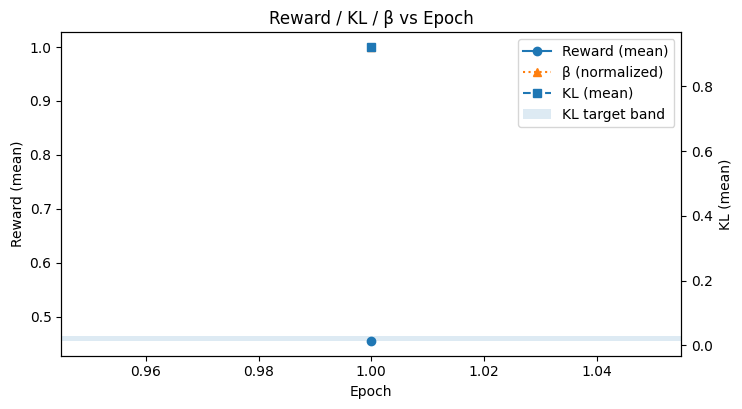

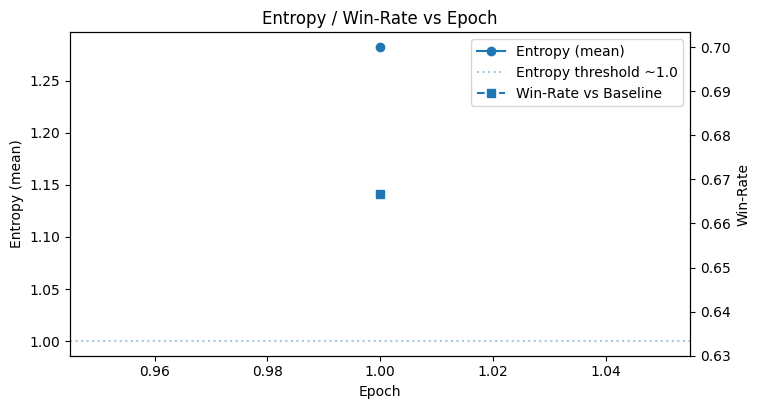

In [13]:
# ============================================================
# Block 9 — Evaluation Dashboard (2 inline plots)
# ------------------------------------------------------------
# - Plot 1: Reward / KL / β vs epoch  (KL target band shaded)
# - Plot 2: Entropy / Win-Rate vs epoch
# - Uses only matplotlib; one chart per figure; no file writes.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Prereqs ----
try:
    ppo_df
except NameError:
    # If notebook state was reset, rebuild from PPO_METRICS
    try:
        PPO_METRICS
        ppo_df = pd.DataFrame(PPO_METRICS)
    except NameError as e:
        raise RuntimeError("No PPO metrics found. Run Blocks 7–8 first.") from e

if ppo_df.empty:
    raise RuntimeError("ppo_df is empty. Run Blocks 7–8 to populate metrics.")

TARGET_KL = globals().get("TARGET_KL", 0.02)

# ---- Plot 1: Reward / KL / β vs epoch ----
fig1 = plt.figure(figsize=(8, 4.2))
ax1 = fig1.add_subplot(111)

epochs = ppo_df["epoch"].to_numpy()
reward_mean = ppo_df["reward_mean"].to_numpy()
kl_mean = ppo_df["kl_mean"].to_numpy()
beta_vals = ppo_df["beta"].to_numpy()

# Reward (left y-axis)
ax1.plot(epochs, reward_mean, marker="o", label="Reward (mean)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Reward (mean)")

# KL (right y-axis)
ax2 = ax1.twinx()
ax2.plot(epochs, kl_mean, marker="s", linestyle="--", label="KL (mean)")
ax2.set_ylabel("KL (mean)")

# KL target band
ax2.axhspan(TARGET_KL/1.5, TARGET_KL*1.5, alpha=0.15, label="KL target band")

# β (secondary overlay using normalized scale for visibility)
# Normalize β for overlay if magnitude is far from Reward/KL
if len(beta_vals) > 0 and np.nanmax(beta_vals) > 0:
    beta_norm = beta_vals / (np.nanmax(beta_vals) or 1.0)
    ax1.plot(epochs, beta_norm, marker="^", linestyle=":", label="β (normalized)")

# Legends: combine both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="best")

ax1.set_title("Reward / KL / β vs Epoch")
plt.show()

# ---- Plot 2: Entropy / Win-Rate vs epoch ----
fig2 = plt.figure(figsize=(8, 4.2))
ax3 = fig2.add_subplot(111)

entropy_mean = ppo_df["entropy_mean"].to_numpy()
win_rate = ppo_df["win_rate_vs_baseline"].to_numpy()

ax3.plot(epochs, entropy_mean, marker="o", label="Entropy (mean)")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Entropy (mean)")

ax4 = ax3.twinx()
ax4.plot(epochs, win_rate, marker="s", linestyle="--", label="Win-Rate vs Baseline")
ax4.set_ylabel("Win-Rate")

# Add a visual cue for potential entropy collapse (teaching threshold ~1.0)
ax3.axhline(1.0, linestyle=":", alpha=0.4, label="Entropy threshold ~1.0")

lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc="best")

ax3.set_title("Entropy / Win-Rate vs Epoch")
plt.show()


# Block 10 — Reflection & Summary

### 🎯 Objective Recap
In this lab you extended your **Offline RLHF pipeline (Lab 02)** into a **hybrid online PPO simulation** where the model learns through live rollouts guided by a reward model.

You implemented the full RLHF fine-tuning loop, step by step:

| Stage | Concept | What We Built |
|--------|----------|----------------|
| **Lab 01** | Reward Model Rθ | A small neural model that predicts scalar reward for (prompt, response) pairs |
| **Lab 02** | Offline Tuning | Cached generations and reward scores, used for offline DPO/PPO simulation |
| **Lab 03 (this lab)** | Online PPO Simulation | Generated fresh responses, evaluated with Rθ, updated policy πϕ using PPO |

---

### 🧩 Step-by-Step Review

**1. Environment Setup**  
We prepared a self-contained folder structure (`class03`) with mock assets, dependencies, and local paths to previous labs.

**2. Cache Loading**  
Loaded the replay buffer (`cache.csv`) containing prompts, baseline responses, model responses, and rewards.  
This gave us a warm-start dataset to bootstrap online updates.

**3. Reward Model (Rθ)**  
Loaded a small bag-of-words style reward model trained in Lab 01 (or mock-initialized).  
It scores prompt–response pairs and produces reward estimates for PPO.

**4. Policy Initialization (πϕ) and Reference (π_ref)**  
Used `distilgpt2` as the base language model.  
We duplicated the model to create:
- **π_ref** → frozen, acts as a KL anchor.  
- **πϕ** → partially trainable (top layers) to allow safe adaptation.

**5. Online Rollouts**  
Generated new responses to prompts using nucleus sampling (temperature 0.7).  
We recomputed:
- log-probs (πϕ)  
- entropy (diversity)  
- KL divergence (πϕ ‖ π_ref)  

**6. Reward Scoring & Advantage Computation**  
Each rollout response was scored by Rθ.  
A lightweight critic network Vψ estimated baseline values, giving:
\[
A_t = R_\theta(x,y) - V_\psi(x,y)
\]
Advantages were standardized to stabilize PPO.

**7. PPO Update with Dynamic β Controller**  
Performed short epochs of PPO updates:  
- Policy gradient with clipping (`ε=0.2`)  
- KL penalty term weighted by β  
- **Dynamic β controller** adjusted β to keep mean KL near the target (~0.02):  
  - KL ↑ → β ↑ (penalize more, slow down learning)  
  - KL ↓ → β ↓ (allow faster adaptation)  

**8. Metric Logging & Diagnostics**  
Tracked reward, KL, entropy, and β per epoch, plus a simple **win-rate vs baseline** using Rθ-scores.  
Flags identified:
- `kl_band_ok` — whether KL stayed in target range.  
- `entropy_low` — potential collapse warning.

**9. Evaluation Dashboard**  
Two plots summarized training dynamics:  
- **Reward / KL / β vs Epoch** — shows the controller stabilizing KL while reward improves.  
- **Entropy / Win-Rate vs Epoch** — highlights diversity and comparative gains.

---

### 🧠 Reflection Prompts

1. **What did the β controller achieve?**  
   - It balanced learning speed and safety by regulating how far the updated policy diverged from the reference.  
   - When KL drifted high, β increased to restrain updates; when KL was too low, β relaxed to allow exploration.  

2. **When did entropy collapse? Why does it matter?**  
   - Entropy fell when the policy became over-confident (low diversity).  
   - In real RLHF, low entropy implies fewer creative variations — often leading to over-optimization on the reward model (reward hacking).  

3. **Any signs of reward hacking?**  
   - Reward hacking would appear as high reward scores but low diversity (entropy ↓) and possibly degraded linguistic quality.  
   - A healthy run should show reward ↑, KL ≈ target, and entropy steady.

4. **What would you try next?**  
   - Add **entropy bonus** (`ENTROPY_COEF > 0`) to maintain diversity.  
   - Train the critic longer for better value estimates.  
   - Evaluate against human preference data for true win-rate.  
   - Explore DPO (Direct Preference Optimization) as an alternative.

---

### 🧩 Key Takeaway
> **Reward-Guided Fine-Tuning** is about **aligning improvement (higher rewards)** with **stability (bounded KL, steady entropy)**.  
> PPO + dynamic β achieves this balance, letting us simulate RLHF safely even in a small, educational setup.

---

### ✅ Deliverables Recap
| File | Purpose |
|-------|----------|
| `lab03_online_ppo.ipynb` | Complete Colab/VSCode notebook |
| `logs/session03_metrics.csv` | (Optional) serialized metrics |
| `report.md` | Reflection answers (this section) |

---

**End of Lab 03 — Reward-Guided Fine-Tuning & Policy Evaluation**
